In [2]:
!pip install tensorflow

In [57]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(320, 320, 3), 
    include_top=False, 
    weights='imagenet',
    pooling='avg'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dense(2, activation='softmax')  
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)        │ (None, 576)                 │         939,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │           1,154 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 940,274 (3.59 MB)

 Trainable params: 1,154 (4.51 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [58]:
base_model.trainable = True

print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  158


In [59]:
fine_tune_at = len(base_model.layers) - 25

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [60]:
# 1. 기본 설정 (MobileNetV3 입력 크기에 맞춤)
batch_size = 32
img_height = 320
img_width = 320

# 1. 학습용(Train) 데이터: train 폴더의 80%만 사용
train_ds = tf.keras.utils.image_dataset_from_directory(
    'C:/Users/User/Downloads/full_images/RGB/RGB_dataset/train',
    validation_split=0.2,      # 전체 데이터의 20%를 검증용으로 빼둠
    subset="training",         # 이 변수에는 나머지 80%인 학습용만 할당
    seed=123,                  # 랜덤하게 섞어서 나눌 때 기준이 되는 시드 번호 (필수)
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

# 2. 검증용(Validation) 데이터: train 폴더의 나머지 20%를 사용 (model.fit에 들어감)
val_ds = tf.keras.utils.image_dataset_from_directory(
    'C:/Users/User/Downloads/full_images/RGB/RGB_dataset/train',
    validation_split=0.2,      # 위와 동일한 비율 지정
    subset="validation",       # 이 변수에는 빼둔 20%의 검증용만 할당
    seed=123,                  # 위와 동일한 시드 번호를 써야 데이터가 겹치지 않음!
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

# 3. 최종 테스트용(Test) 데이터: test 폴더의 데이터는 오직 평가용으로만 사용!
test_ds = tf.keras.utils.image_dataset_from_directory(
    'C:/Users/User/Downloads/full_images/RGB/RGB_dataset/test',
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

# 4. 클래스 매핑 확인 (알파벳 순서에 따라 fail: 0, pass: 1 로 지정됨)
class_names = train_ds.class_names
print(f"클래스 인덱스: 0={class_names[0]}, 1={class_names[1]}")

# 5. 데이터 로딩 성능 최적화 (Prefetch & Cache)
# 디스크에서 이미지를 읽어오는 동안 CPU/GPU가 쉬지 않도록 미리 다음 데이터를 메모리에 준비시키는 작업입니다.
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 19000 files belonging to 2 classes.
Using 15200 files for training.
Found 19000 files belonging to 2 classes.
Using 3800 files for validation.
Found 1000 files belonging to 2 classes.
클래스 인덱스: 0=fail, 1=pass


In [61]:
class_weights_dict = {
    0: 1.0,  
    1: 1.0   
}

epochs = 10
print("학습을 시작합니다...")

history = model.fit(
    train_ds,   
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weights_dict
)

학습을 시작합니다...
Epoch 1/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 728s 1s/step - accuracy: 0.9017 - loss: 0.2890 - val_accuracy: 0.9063 - val_loss: 0.2967
Epoch 2/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 628s 1s/step - accuracy: 0.9227 - loss: 0.2165 - val_accuracy: 0.9074 - val_loss: 0.2823
Epoch 3/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 650s 1s/step - accuracy: 0.9444 - loss: 0.1773 - val_accuracy: 0.9166 - val_loss: 0.2416
Epoch 4/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 705s 1s/step - accuracy: 0.9566 - loss: 0.1503 - val_accuracy: 0.9371 - val_loss: 0.1935
Epoch 5/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 597s 1s/step - accuracy: 0.9640 - loss: 0.1308 - val_accuracy: 0.9505 - val_loss: 0.1554
Epoch 6/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 727s 1s/step - accuracy: 0.9693 - loss: 0.1170 - val_accuracy: 0.9605 - val_loss: 0.1285
Epoch 7/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 555s 1s/step - accuracy: 0.9717 - loss: 0.1069 - val_accuracy: 0.9689 - val_loss: 0.1111
Epoch 8/10
475/475 ━━━━━━━━━━━━━━━━━━━━ 610s 1s/step - accuracy: 0.9737 - loss: 0.09

In [62]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

predictions = model.predict(test_ds)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

if len(y_true.shape) > 1:
    y_true = np.argmax(y_true, axis=1)


테스트 데이터 예측을 시작합니다...
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 995ms/step


In [63]:
y_pred = np.argmax(predictions, axis=1)

class_names = ['fail', 'pass']
print("\n=== 상세 분류 리포트 ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. 오차 행렬 (Confusion Matrix) 출력
print("\n=== 오차 행렬 (Confusion Matrix) ===")
cm = confusion_matrix(y_true, y_pred)
print(f"               [예측: fail]  [예측: pass]")
print(f"[실제: fail]       {cm[0, 0]}            {cm[0, 1]}")
print(f"[실제: pass]       {cm[1, 0]}            {cm[1, 1]}")


=== 상세 분류 리포트 ===
              precision    recall  f1-score   support

        fail       1.00      0.74      0.85       100
        pass       0.97      1.00      0.99       900

    accuracy                           0.97      1000
   macro avg       0.99      0.87      0.92      1000
weighted avg       0.97      0.97      0.97      1000


=== 오차 행렬 (Confusion Matrix) ===
               [예측: fail]  [예측: pass]
[실제: fail]       74            26
[실제: pass]       0            900


In [64]:
y_pred_custom = np.where(predictions[:, 0] >= 0.3, 0, 1)

class_names = ['fail', 'pass']
print("\n=== 상세 분류 리포트 ===")
print(classification_report(y_true, y_pred_custom, target_names=class_names))

# 4. 오차 행렬 (Confusion Matrix) 출력
print("\n=== 오차 행렬 (Confusion Matrix) ===")
cm = confusion_matrix(y_true, y_pred_custom)
print(f"               [예측: fail]  [예측: pass]")
print(f"[실제: fail]       {cm[0, 0]}            {cm[0, 1]}")
print(f"[실제: pass]       {cm[1, 0]}            {cm[1, 1]}")


=== 상세 분류 리포트 ===
              precision    recall  f1-score   support

        fail       0.99      0.79      0.88       100
        pass       0.98      1.00      0.99       900

    accuracy                           0.98      1000
   macro avg       0.98      0.89      0.93      1000
weighted avg       0.98      0.98      0.98      1000


=== 오차 행렬 (Confusion Matrix) ===
               [예측: fail]  [예측: pass]
[실제: fail]       79            21
[실제: pass]       1            899


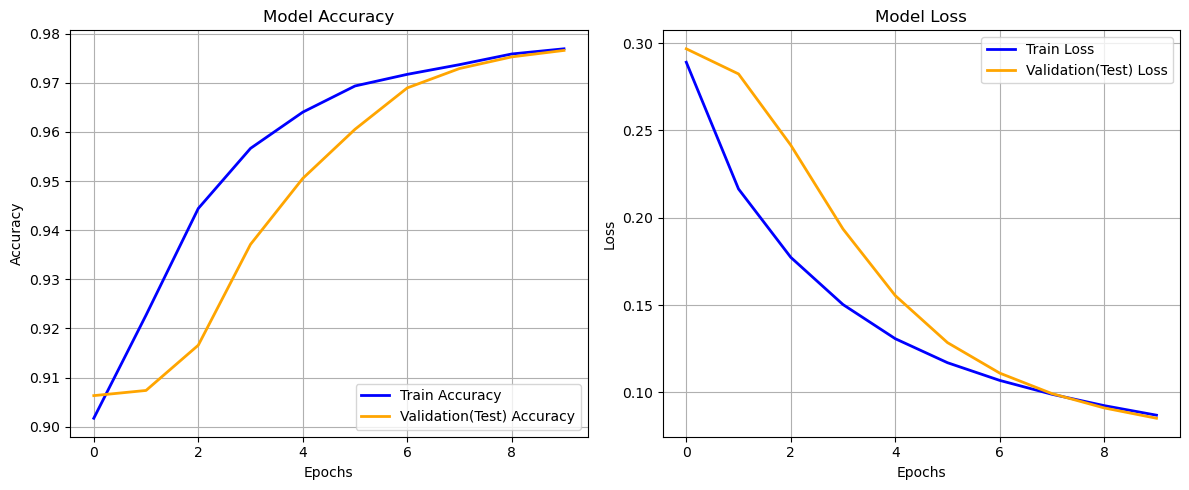

In [65]:
import matplotlib.pyplot as plt

# model.fit() 실행 결과를 history 변수에 저장했다고 가정합니다.
# 예: history = model.fit(train_dataset, validation_data=val_dataset, epochs=20, class_weight=weights)

# 1. 전체 그래프 캔버스 크기 설정 (가로 12, 세로 5)
plt.figure(figsize=(12, 5))

# 2. 정확도(Accuracy) 그래프 그리기
plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째 영역
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation(Test) Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# 3. 손실(Loss) 그래프 그리기
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째 영역
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation(Test) Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# 4. 레이아웃 겹치지 않게 조정한 뒤 출력
plt.tight_layout()
plt.show()

In [67]:
import tensorflow as tf
import os

# 1. 파일명만 훔쳐오기 위한 '가짜 데이터셋'을 아주 빠르게 생성합니다. (학습 X)
# 경로 부분은 실제 테스트 데이터가 있는 폴더 경로로 맞춰주세요.
dummy_dataset = tf.keras.utils.image_dataset_from_directory(
    'C:/Users/User/Downloads/full_images/RGB/RGB_dataset/test',  
    shuffle=False,  # 순서가 섞이지 않게 고정 (핵심)
    batch_size=32,
    image_size=(320, 320)
)

# 2. 여기서 경로 리스트만 쏙 빼옵니다.
file_paths = dummy_dataset.file_paths


Found 1000 files belonging to 2 classes.


놓친 불량(미검) 개수: 26개


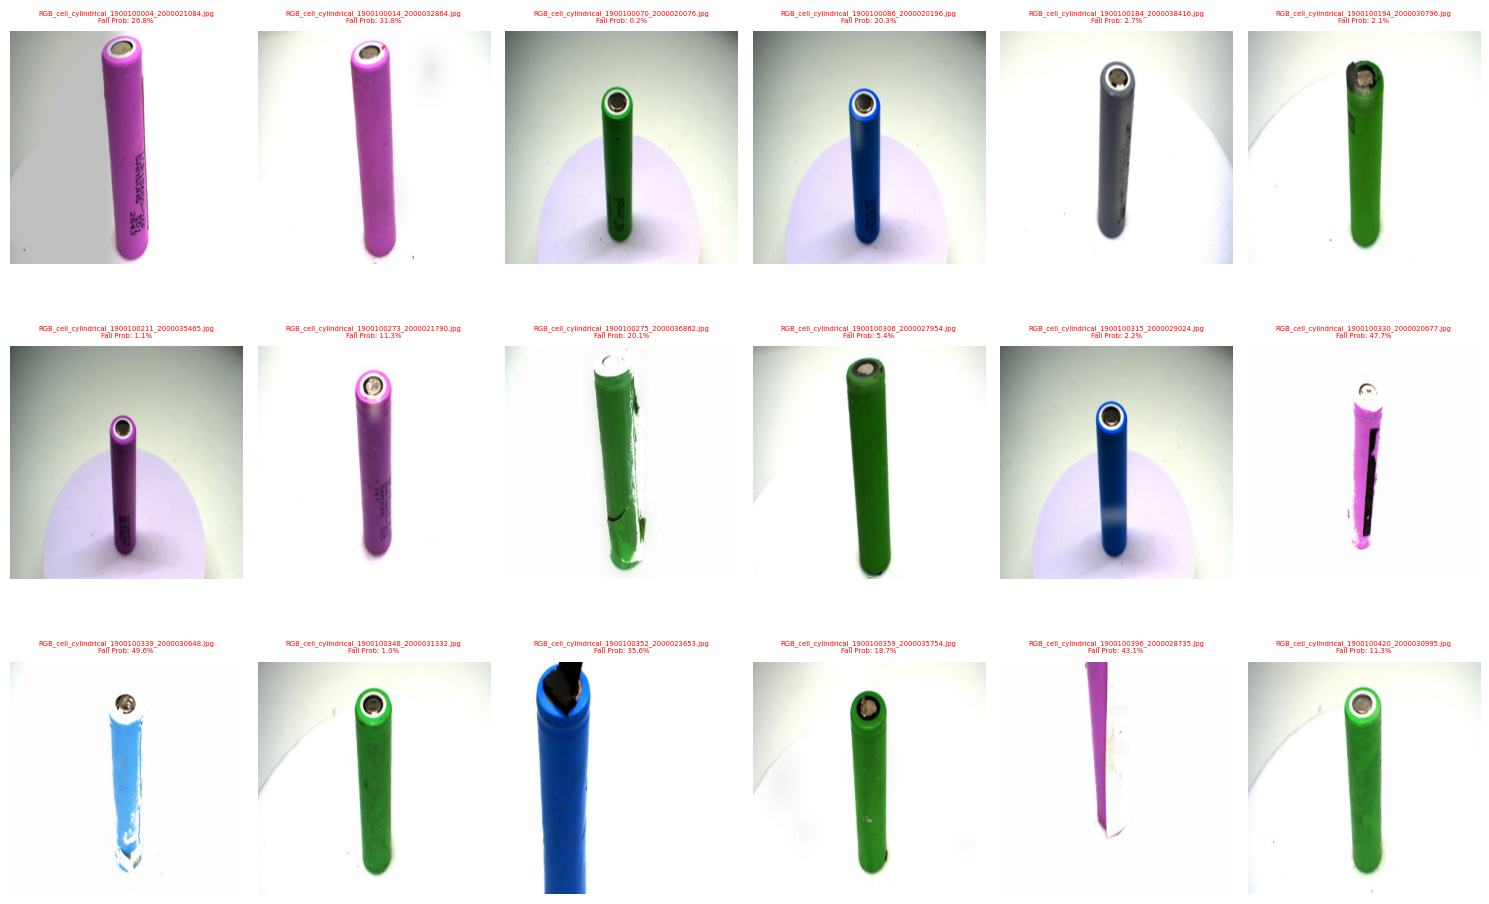

In [68]:
# 1. 미검(False Negative) 데이터의 인덱스 찾기
missed_indices = np.where((y_true == 0) & (y_pred == 1))[0]
print(f"놓친 불량(미검) 개수: {len(missed_indices)}개")

# 3. 테스트 데이터셋에서 전체 이미지 배열 가져오기
all_images = np.concatenate([x for x, y in test_ds], axis=0)

# 4. 시각화 (matplotlib)
plt.figure(figsize=(15, 10))
f_name=[]
for i, idx in enumerate(missed_indices):
    if i >= 18:  # 18개까지만 출력
        break
        
    plt.subplot(3, 6, i + 1)
    
    img = all_images[idx]
    if np.max(img) > 1.0:
        img = img.astype("uint8")
        
    plt.imshow(img)
    
    # [수정] 인덱스 대신 파일명 추출하기
    # os.path.basename을 사용하면 전체 경로에서 파일 이름(예: image_123.jpg)만 똑 떼어옵니다.
    filename = os.path.basename(file_paths[idx])
    
    # 모델이 불량(fail)일 확률 계산값 가져오기
    fail_prob = predictions[:, 0][idx] * 100 
    
    # 제목에 파일명과 확률 표시 (글씨가 길어질 수 있으므로 폰트 크기 조정)
    plt.title(f"{filename}\nFail Prob: {fail_prob:.1f}%", fontsize=5, color='red')
    plt.axis('off')
    f_name.append(filename)

plt.tight_layout()
plt.show()

In [69]:
f_name

['RGB_cell_cylindrical_1900100004_2000021084.jpg',
 'RGB_cell_cylindrical_1900100014_2000032864.jpg',
 'RGB_cell_cylindrical_1900100070_2000020076.jpg',
 'RGB_cell_cylindrical_1900100086_2000020196.jpg',
 'RGB_cell_cylindrical_1900100184_2000038416.jpg',
 'RGB_cell_cylindrical_1900100194_2000030796.jpg',
 'RGB_cell_cylindrical_1900100211_2000035465.jpg',
 'RGB_cell_cylindrical_1900100273_2000021790.jpg',
 'RGB_cell_cylindrical_1900100275_2000036862.jpg',
 'RGB_cell_cylindrical_1900100306_2000027954.jpg',
 'RGB_cell_cylindrical_1900100315_2000029024.jpg',
 'RGB_cell_cylindrical_1900100330_2000020677.jpg',
 'RGB_cell_cylindrical_1900100339_2000030648.jpg',
 'RGB_cell_cylindrical_1900100348_2000031332.jpg',
 'RGB_cell_cylindrical_1900100352_2000023653.jpg',
 'RGB_cell_cylindrical_1900100359_2000035754.jpg',
 'RGB_cell_cylindrical_1900100396_2000028735.jpg',
 'RGB_cell_cylindrical_1900100420_2000030995.jpg']

In [70]:
# C드라이브의 특정 폴더에 저장하고 싶을 때
model.save('C:/Users/User/Downloads/saved_models/inspection_model_test_1.keras')

print("원하는 디렉토리에 모델이 저장되었습니다.")

원하는 디렉토리에 모델이 저장되었습니다.
